<a href="https://colab.research.google.com/github/Lingeshkumar24-code/NLP-projects/blob/main/NLP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np #for math basic
import re  #regular expresssions cleaning the data
import nltk #for basic
import matplotlib.pyplot as plt  #visulization
from nltk.corpus import stopwords #to remove be verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

In [4]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download("punkt_tab")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [6]:
print("customer reviews dataset")
print(df.head())

customer reviews dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [7]:
stop_words = set(stopwords.words('english'))

In [19]:
def clean_text(text):
  text = text.lower()
  print('lower case',text)
  text = re.sub(r'[^a-zA-Z\s]','',text)
  print("special character",text)

  words = word_tokenize(text)
  print("tokenization",words)

  words = [word for word in words if word not in stop_words]
  print("stop words",words)

  cleaned_text = " ".join(words)

  return cleaned_text




In [20]:
df['cleaned_review'] = df['Review'].apply(clean_text)
print("\ncleaned Review")
print(df[['Review','cleaned_review']])

lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stop words ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stop words ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stop words ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delive

In [21]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(Review):
  score = sia.polarity_scores(Review)
  compound = score['compound']
  if score['compound'] >= 0.05:
    return 'Positive'
  elif score['compound'] <= -0.05:
    return 'Negative'
  else:
    return 'Neutral'



In [22]:
df["Sentiment"] = df["cleaned_review"].apply(analyze_sentiment)
print("\nSentiment Analysis")
print(df[["Review","Sentiment"]])


Sentiment Analysis
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [23]:
all_words = " ".join(df['cleaned_review'])

word_list = all_words.split()

print("\n top 10 common keywords")

print(Counter(word_list).most_common(10))


 top 10 common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [24]:
negative_review = df[df['Sentiment']=='Negative']
negative_words = " ".join(negative_review['cleaned_review'])

word_list = negative_words.split()

print("\n top 10 negative keywords")

print(Counter(word_list).most_common(10))


 top 10 negative keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [26]:
sentiment_counts = df["Sentiment"].value_counts()
sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


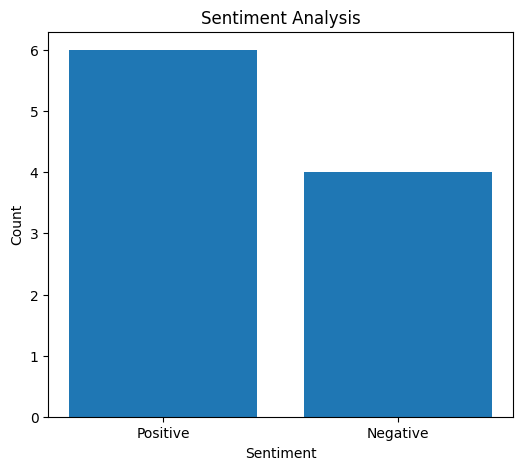

In [25]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Analysis")
plt.show()

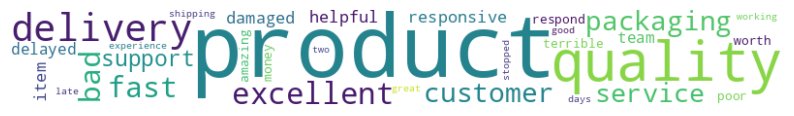

In [31]:
wordcloud = WordCloud(
    width = 800,
    height = 100,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.show()